In [ ]:
#NAME: Shaza Adelina
#ID:SN0107857
#LAB10

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


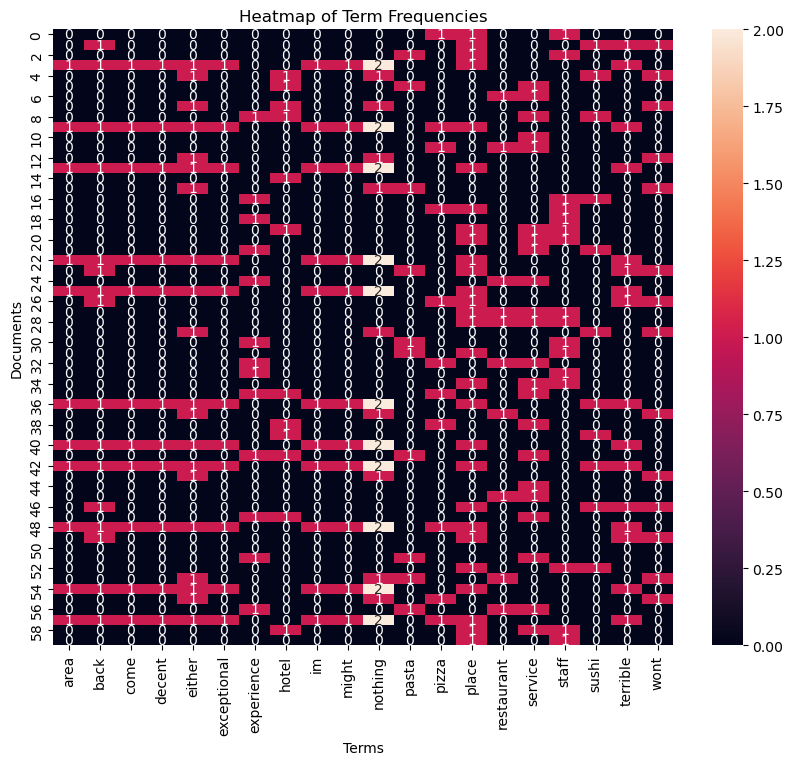

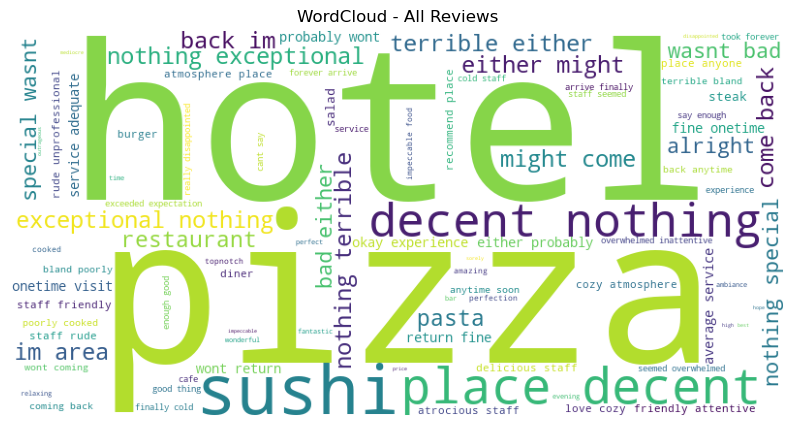

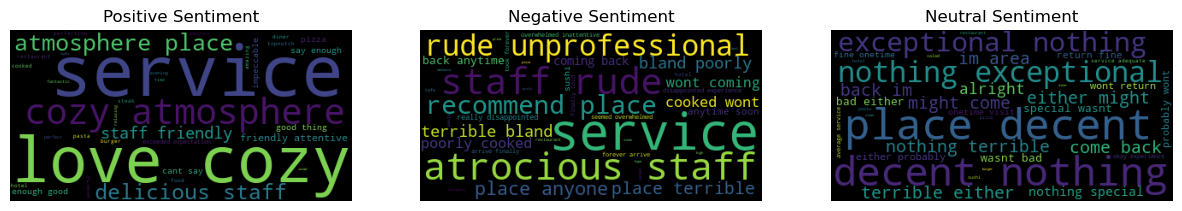

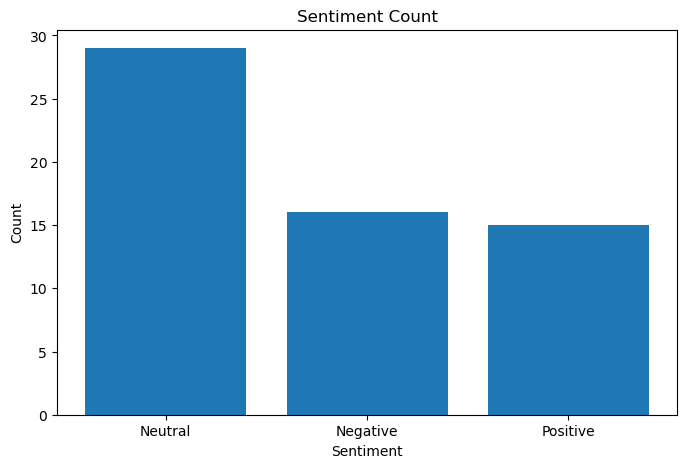

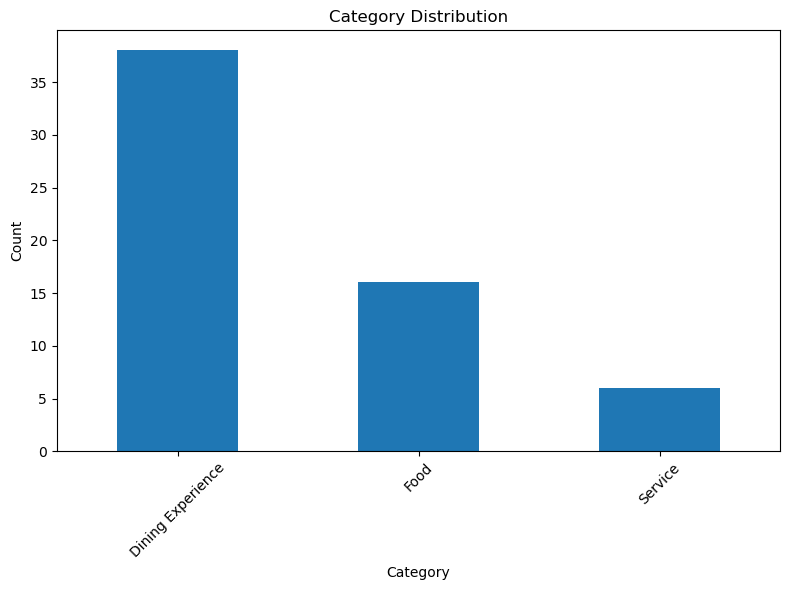

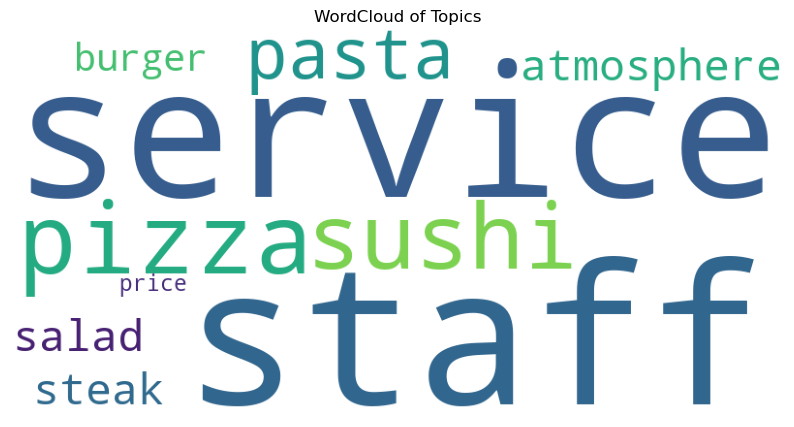

In [2]:
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
from collections import Counter

# download nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# load dataset
df = pd.read_csv('restaurant_reviews.csv')

# lemmatizer
lemmatizer = WordNetLemmatizer()

# preprocessing function
def preprocess_review(review):
    review = str(review)
    review = review.lower()
    review = re.sub(r'[^\w\s]', '', review)
    review = re.sub(r'\d+', '', review)

    tokens = word_tokenize(review)

    stop_words = set(stopwords.words('english'))
    tokens = [w for w in tokens if w not in stop_words]

    tokens = [lemmatizer.lemmatize(w) for w in tokens]

    return ' '.join(tokens)

# apply preprocessing
df['preprocessed_text'] = df['Review'].apply(preprocess_review)

# HEATMAP
vectorizer = CountVectorizer(max_features=20)
X = vectorizer.fit_transform(df['preprocessed_text'])
term_freq_matrix = X.toarray()
terms = vectorizer.get_feature_names_out()

plt.figure(figsize=(10, 8))
sns.heatmap(term_freq_matrix, xticklabels=terms, annot=True)
plt.title("Heatmap of Term Frequencies")
plt.xlabel("Terms")
plt.ylabel("Documents")
plt.show()


# WORDCLOUD 
all_text = " ".join(df['preprocessed_text'])
wc = WordCloud(width=800, height=400, background_color='white').generate(all_text)

plt.figure(figsize=(10, 6))
plt.imshow(wc)
plt.axis('off')
plt.title("WordCloud - All Reviews")
plt.show()


# SENTIMENT WORDCLOUDS
pos_text = " ".join(df[df['Sentiment']=='Positive']['preprocessed_text'])
neg_text = " ".join(df[df['Sentiment']=='Negative']['preprocessed_text'])
neu_text = " ".join(df[df['Sentiment']=='Neutral']['preprocessed_text'])

wc_pos = WordCloud().generate(pos_text)
wc_neg = WordCloud().generate(neg_text)
wc_neu = WordCloud().generate(neu_text)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(wc_pos)
plt.title("Positive Sentiment")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(wc_neg)
plt.title("Negative Sentiment")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(wc_neu)
plt.title("Neutral Sentiment")
plt.axis('off')

plt.show()


# SENTIMENT BAR CHART
sentiment_counts = df['Sentiment'].value_counts()

plt.figure(figsize=(8,5))
plt.bar(sentiment_counts.index, sentiment_counts.values)
plt.title("Sentiment Count")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()


# CATEGORY BAR CHART
category_counts = df['Category'].value_counts()

plt.figure(figsize=(8,6))
category_counts.plot(kind='bar')
plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# TOPIC WORDCLOUD 
topics_clean = df['Topics'].dropna()

all_topics = []
for row in topics_clean:
    all_topics.extend(row.split(', '))

topic_counts = Counter(all_topics)

wc_topics = WordCloud(width=800, height=400, background_color='white') \
    .generate_from_frequencies(topic_counts)

plt.figure(figsize=(10,6))
plt.imshow(wc_topics)
plt.axis('off')
plt.title("WordCloud of Topics")
plt.show()
